# CS 5864: Homework 3, Part 2

In this exercise, you will develop a one-stage detector inspired by [FCOS: Fully-Convolutional One-Stage Object Detection](https://arxiv.org/abs/1904.01355). Your task is to build and train a model designed to detect various object categories.

Our architecture mirrors the core principles of FCOS; however, we opt for a more compact variant with some adjusted hyperparameters to efficiently operate within Colab's resource constraints.

Detection performance will be measured using the traditional mean Average Precision metric ([mAP](https://github.com/Cartucho/mAP)).

## Google Colab Setup
The following part only applies to students using Colab. If you're not using Colab, feel free to delete this.

In [ ]:
# from google.colab import drive
# drive.mount("")

In [ ]:
# import os
# datadir = "" # path to the homework
# if not os.path.exists(datadir):
#   !ln -s "" $datadir # path to the homework
# os.chdir(datadir)
# !pwd

## Setup Code
Before diving into the assignment, let’s get our environment ready. Just like in earlier assignments, we’ll begin with some essential setup. Make sure to execute this cell each time you open or restart the notebook.

To start, we’ll load the autoreload extension. This makes it easier to work with external .py files by automatically updating any changes when we re-import them into the notebook. It’s a handy tool for smooth development and testing.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time
import random
import matplotlib.pyplot as plt
import torch
import torchvision

%matplotlib inline

from fcos_starter import *

# for plotting
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # set default size of plots
plt.rcParams["font.size"] = 16
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

# for mAP eval
!rm -rf mAP
!git clone https://github.com/Cartucho/mAP.git
!rm -rf mAP/input/*

def rel_error(x, y, eps=1e-10):
    top = (x - y).abs().max().item()
    bot = (x.abs() + y.abs()).clamp(min=eps).max().item()
    return top / bot

Cloning into 'mAP'...
remote: Enumerating objects: 908, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 908 (delta 135), reused 125 (delta 125), pack-reused 758 (from 1)
Receiving objects: 100% (908/908), 14.70 MiB | 39.52 MiB/s, done.
Resolving deltas: 100% (329/329), done.


In [3]:
if torch.cuda.is_available():
    print("All set – using GPU.")
    COMPUTE_DEVICE = torch.device("cuda")
else:
    print("GPU not detected. Please enable it in Notebook Settings under Edit.") #if using Google Colab
    COMPUTE_DEVICE = torch.device("cpu")

All set – using GPU.


## Download and Prepare the PASCAL VOC 2007 Object Detection Dataset

Object detection requires datasets where each image is annotated with *bounding boxes*. Each bounding box specifies both the category label and the spatial extent of an object within the image.

To support this, we will use the [PASCAL VOC 2007](https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/index.html) dataset, which provides detailed annotations of this type. Historically, the PASCAL VOC competitions were held annually from 2005 to 2012 and preceded challenges such as ImageNet discussed in our classes. The 2007 dataset became one of the standard benchmarks for object detection and, being smaller than newer datasets like [COCO](http://cocodataset.org/#home), is well-suited for a homework assignment.

The dataset contains annotated bounding boxes for 20 object classes:
`["aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat", "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"]`.

In the helper file `fcos_starter.py`, we have created a [`PyTorch Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) class, named as `VOC07TinyDetDataset`, that automatically downloads and prepares the PASCAL VOC 2007 dataset. This class returns the image annotations as a nested structure of dictionaries.

Run the following two cells to set the configuration parameters and download the train/validation sets for the PASCAL VOC 2007 dataset.

In [4]:
import multiprocessing

NUM_CLASSES = 20
BATCH_SIZE = 16
IMAGE_SHAPE = (224, 224)
NUM_WORKERS = multiprocessing.cpu_count()

In [5]:
%pip install wget

Note: you may need to restart the kernel to use updated packages.


In [6]:
!wget https://web.eecs.umich.edu/~justincj/data/VOCtrainval_06-Nov-2007.tar


--2025-11-21 17:19:51--  https://web.eecs.umich.edu/~justincj/data/VOCtrainval_06-Nov-2007.tar
Resolving web.eecs.umich.edu (web.eecs.umich.edu)... 141.212.113.214
Connecting to web.eecs.umich.edu (web.eecs.umich.edu)|141.212.113.214|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 460032000 (439M) [application/x-tar]
Saving to: ‘VOCtrainval_06-Nov-2007.tar’

VOCtrainval_06-Nov- 100%[===================>] 438.72M  71.6MB/s    in 5.4s    

2025-11-21 17:19:57 (81.3 MB/s) - ‘VOCtrainval_06-Nov-2007.tar’ saved [460032000/460032000]



In [7]:
import shutil
GOOGLE_DRIVE_PATH = "data/"
shutil.move("VOCtrainval_06-Nov-2007.tar", os.path.join(GOOGLE_DRIVE_PATH, "VOCtrainval_06-Nov-2007.tar"))
from fcos_starter import VOC07TinyDetDataset

train_dataset = VOC07TinyDetDataset(
    GOOGLE_DRIVE_PATH, "train", image_size=IMAGE_SHAPE[0],
    download=True # set to true to download first time
)
val_dataset = VOC07TinyDetDataset(
    GOOGLE_DRIVE_PATH, "val", image_size=IMAGE_SHAPE[0],
    download=True  # set to true to download first time
)

print(f"Dataset sizes: train ({len(train_dataset)}), val ({len(val_dataset)})")

Dataset sizes: train (2501), val (2510)


Next, you need to load the images and the bounding boxes into tensors. We have this already done in `fcos_starter.py`. You don't need to understand how it works, just make sure you understand the output format.

In [8]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, pin_memory=True, num_workers=NUM_WORKERS
)

# we are using batch 1 at inference since images might be diff size and we don't do center crop
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=1, pin_memory=True, num_workers=NUM_WORKERS
)

### Loading in Data

The `DataLoader` instance provides data in batches.

For each batch, the initial output is a Tensor called `image` with dimensions `(B, 3, IMAGE_SHAPE[0], IMAGE_SHAPE[1])`. This tensor represents a batch containing `B` images, akin to the images seen in typical classification datasets.

Following that, the second output is a Tensor termed `gt_boxes`, which has the shape `(B, N, 5)`. This tensor encodes details about every object found across all images in the batch. Specifically, each element `gt_boxes[i, j] = (x1, y1, x2, y2, C)` describes the `j`th object within the image `image[i]`: `(x1, y1)` corresponds to the top-left corner of the bounding box, while `(x2, y2)` (note: the earlier text mistakenly repeated `x2`) represents the bottom-right corner. All coordinates are floating-point numbers within the range `[0, 224]`, and `C` is an integer representing the category label for that object. This bounding box style, denoted by `(x1, y1, x2, y2)`, is widely known as the XYXY format.

Since each image might include a different quantity of objects, if an image `image[i]` contains $N_i$ objects, then $N = \max_i(N_i)$ is used to denote the maximum number of objects present in any image of the batch, and this can change with each batch. For any image having fewer than $N$ objects, only the initial $N_i$ rows of `gt_boxes[i]` contain valid annotations; the remaining rows are filled with -1 to indicate padding.


In [9]:
train_loader_iter = iter(train_loader)
image_paths, images, gt_boxes = next(train_loader_iter)

print(f"img paths           : {image_paths}")
print(f"img batch shape : {images.shape}")
print(f"gt_boxes shape    : {gt_boxes.shape}")

print(f"Printing five boxes per image  :")
print(gt_boxes[:, :5, :])

img paths           : ['data/VOCdevkit/VOC2007/JPEGImages/000012.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000017.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000023.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000026.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000032.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000033.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000034.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000035.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000036.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000042.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000044.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000047.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000048.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000061.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000064.jpg', 'data/VOCdevkit/VOC2007/JPEGImages/000066.jpg']
img batch shape : torch.Size([16, 3, 224, 224])
gt_boxes shape    : torch.Size([16, 40, 5])
Printing five boxes per image  :
tensor([[[ 48.9369,  65.2493, 180.1081, 181.6216,   6.0000],
         [ -1.0000,  -1

### Visualizing PASCAL VOC 2007

Before diving into model development, it's a great idea to take a closer look at your training data. Visualizing a few samples can be very helpful—it may reveal issues with your data pipeline or inspire ideas for model improvements.

There’s also a helper function located in `code/utils.py` that we use for drawing detections on images. In this step, you’ll load a few images from the PASCAL VOC 2007 training set and display the ground-truth bounding boxes along with their corresponding class labels.


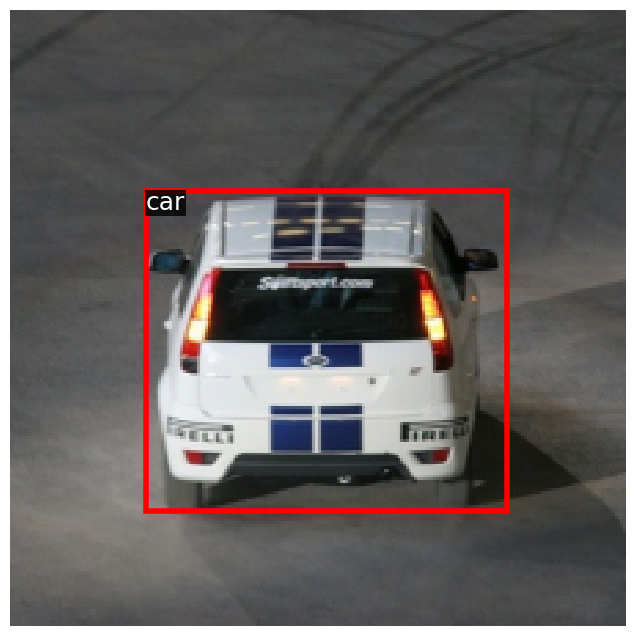

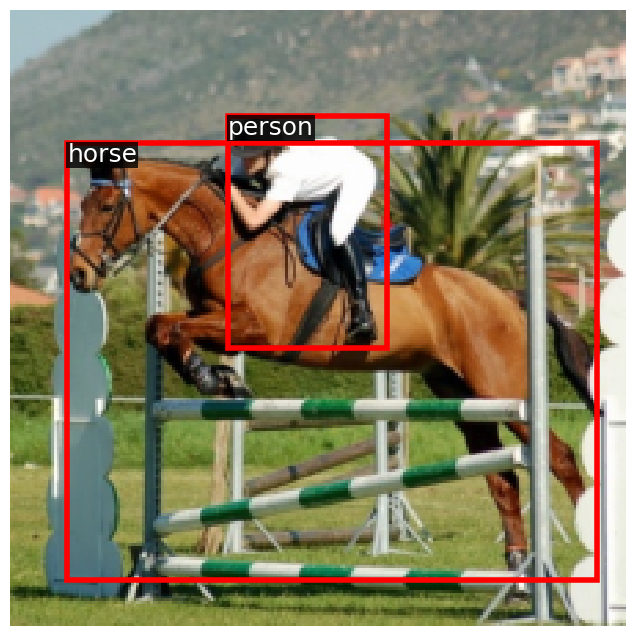

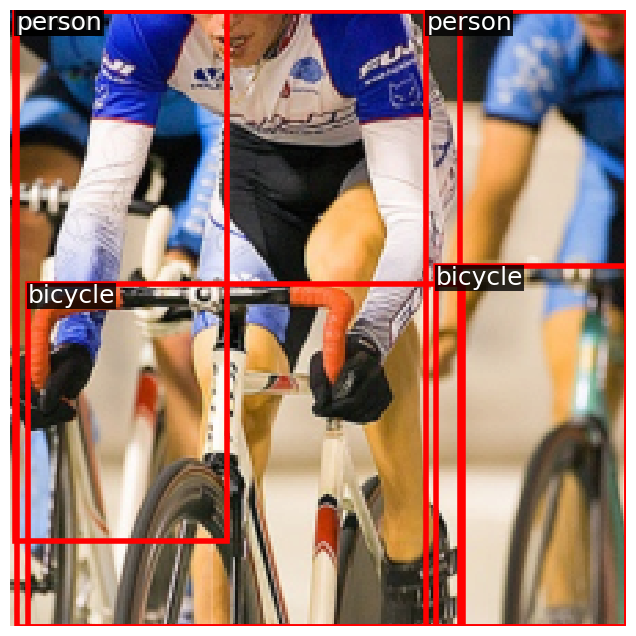

In [10]:
from torchvision import transforms
from mycode.utils import det_vis

inverse_norm = transforms.Compose(
    [
        transforms.Normalize(mean=[0., 0., 0.], std=[1 / 0.229, 1 / 0.224, 1 / 0.225]),
        transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1., 1., 1.]),
    ]
)

for idx, (_, image, gt_boxes) in enumerate(train_dataset):
    if idx > 2:
        break

    image = inverse_norm(image)

    is_valid = gt_boxes[:, 4] >= 0
    det_vis(image, val_dataset.idx_to_class, gt_boxes[is_valid])

## Building the FCOS Detector

FCOS is a single-stage object detection framework that operates fully convolutionally—unlike two-stage detectors such as Faster R-CNN, it doesn’t rely on components like anchor boxes, region proposal networks (RPN), or operations like RoI pooling. Thanks to its simplicity, you'll first construct key parts of the FCOS model in this part of the assignment.

The model design includes three main modules: the backbone, the feature pyramid network (FPN), and the head that generates predictions. A diagram illustrating this pipeline is shown below. If it fails to render, you can view it in [Figure 2 of the FCOS paper](https://arxiv.org/abs/1904.01355).

<img src="https://production-media.paperswithcode.com/methods/Screen_Shot_2020-06-23_at_3.34.09_PM_SAg1OBo.png" alt="FCOS Model Diagram" width="80%">

> **NOTE:** The official FCOS design (as shown in the diagram) places the centerness branch alongside the classification branch. However, in this assignment, we’ll follow the more common implementation approach where the centerness head is positioned in parallel with the box regression branch. This adjustment is based on the rationale that both centerness and box regression are concerned with spatial localization, and may benefit from shared intermediate features.

## Constructing the Backbone and Feature Pyramid Network

We'll begin by implementing the backbone and FPN modules (the blue and green sections in the diagram). These components take an image as input and produce feature maps at multiple scales. The backbone is a convolutional network that progressively reduces spatial resolution, typically using layers like max pooling.

For this assignment, we'll use [RegNetX-400MF](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.regnet_x_400mf.html#torchvision.models.regnet_x_400mf) as our backbone, since it offers a good tradeoff between performance and training speed, especially for running in environments like Google Colab. We've already included the code to load pretrained ImageNet weights and extract intermediate feature maps `c3`, `c4`, and `c5` as shown above.

These features (`c3`, `c4`, `c5`) correspond to progressively smaller spatial scales, with strides of 8, 16, and 32, respectively. That means each movement of one pixel in these feature maps corresponds to a shift of 8, 16, or 32 pixels in the original image.

Next, you’ll need to implement the logic to convert these backbone features into the FPN outputs: `p3`, `p4`, and `p5`. These are referred to as _FPN levels_, and they allow the model to make predictions across multiple object sizes. Refer to Figure 3 in the [FPN paper](https://arxiv.org/abs/1612.03144) for an illustration of how this transformation works.

Before proceeding to implementation, run the following cell to initialize the backbone and inspect the shapes of the `c3`, `c4`, and `c5` feature maps for a sample image:


In [28]:
import torch
from common import DetBackboneFPN

backbone = DetBackboneFPN(out_channels=64)

For dummy input with shape: (2, 3, 224, 224)
Shape of c3 features: torch.Size([2, 64, 28, 28])
Shape of c4 features: torch.Size([2, 160, 14, 14])
Shape of c5 features: torch.Size([2, 400, 7, 7])


At this time, you should proceed to `common.py` and implement more FPN layers to go from `(c3, c4, c5)` to `(p3, p4, p5)`.
We are omitting `(p6,p7)` so it fits on the GPU. Note that the output features from FPN needs to have the same height and width as the backbone features, however, it should also have the same number of channels.

In [29]:
print("Custom FPN layers configured:")
print(backbone.fpn_params)

# Generate a batch of synthetic image data (random tensors) shaped as NCHW and inspect the result.
dummy_images = torch.randn(2, 3, 224, 224)

# Run the synthetic input through the model to get the FPN feature maps.
dummy_fpn_feats = backbone(dummy_images)

print(f"Input tensor dimensions: {dummy_images.shape}")
for level_name, feat in dummy_fpn_feats.items():
    print(f"Output dimensions at {level_name}: {feat.shape}")

Custom FPN layers configured:
ModuleDict(
  (c3): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (c4): Conv2d(160, 64, kernel_size=(1, 1), stride=(1, 1))
  (c5): Conv2d(400, 64, kernel_size=(1, 1), stride=(1, 1))
)
Input tensor dimensions: torch.Size([2, 3, 224, 224])
Output dimensions at p3: torch.Size([2, 64, 28, 28])
Output dimensions at p4: torch.Size([2, 64, 14, 14])
Output dimensions at p5: torch.Size([2, 64, 7, 7])


## Constructing the FCOS Output Layers (Prediction Head)

At this stage, you've already built the backbone and the FPN modules. The next step is to construct the output head, responsible for generating predictions — specifically, object class scores, bounding box coordinates, and centerness values. These are represented by the **orange** components in the diagram above.

Pay particular attention to the right-hand portion of the diagram, which outlines the internal structure of the head module. This component is built using four convolutional layers that generate intermediate feature maps of shape `(H, W, 256)` (note that `H` and `W` differ across FPN levels). These features are then passed into three separate convolutional layers, each responsible for predicting one of the three outputs: classification scores, bounding box offsets, and centerness scores.

Your task is to implement this logic inside the `FCOSPredictionNetwork` class in the `my_detector.py` file. Refer to the inline documentation in the class for additional guidance as you proceed.

When correctly implemented, the output shapes should be as follows:
- The classification output should have `NUM_CLASSES` channels.
- The box regression output should have 4 channels.
- The centerness output should have a single channel.

All outputs should be flattened along the spatial dimensions, so that they are returned in the shape `(B, H * W, C)` — this flattened format simplifies the loss computation process, which you'll get to soon.


In [30]:
from my_detector import MyFCOSNetwork

# Initialize the prediction module with a simple stem architecture:
# The stem includes two convolutional layers and expects inputs from the FPN
pred_net = MyFCOSNetwork(
    num_classes=NUM_CLASSES, in_channels=64, stem_channels=[64, 64]
)

# Display the configuration of the initialized prediction network
print("FCOS prediction network parameters:")
print(pred_net)

# Use the output from the FPN (from an earlier step) as input to the prediction head
dummy_preds = pred_net(dummy_fpn_feats)

# Unpack the outputs: class scores, bounding box deltas, and centerness scores
pred_cls_logits, pred_boxreg_deltas, pred_ctr_logits = dummy_preds

# Print out the shapes of the classification score maps from each FPN level
print("Classification logits:")
for level_name, feat in pred_cls_logits.items():
    print(f"Shape of {level_name} predictions: {feat.shape}")

# Print out the shapes of the box regression outputs from each level
print("Box regression deltas:")
for level_name, feat in pred_boxreg_deltas.items():
    print(f"Shape of {level_name} predictions: {feat.shape}")

# Print out the shapes of the centerness maps from each level
print("Centerness logits:")
for level_name, feat in pred_ctr_logits.items():
    print(f"Shape of {level_name} predictions: {feat.shape}")

FCOS prediction network parameters:
MyFCOSNetwork(
  (stem_cls): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (stem_box): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pred_cls): Conv2d(64, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pred_box): Conv2d(64, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pred_ctr): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
Classification logits:
Shape of p3 predictions: torch.Size([2, 784, 20])
Shape of p4 predictions: torch.Size([2, 196, 20])
Shape of p5 predictions: torch.Size([2, 49, 20])
Box regression deltas:
Shape of p3 predictions: torch.Size([2, 784, 4])
Shape of p4 predictions: torch.Size([2, 1

## Time to train!

At this point, you've completed the implementation of the FCOS architecture and are ready to begin training it!

You may have noticed that all the custom trainable components you've built so far — including the layers within the FPN and the prediction modules — are entirely made up of convolutional operations.  
This is where the term *fully-convolutional* in FCOS comes from: the model carries out object detection solely through convolutional layers, without relying on anchors, region proposals, or other hand-crafted mechanisms.

The upcoming steps will walk you through setting up the training workflow for your FCOS model.

In contrast to image classification tasks, which are typically trained on `(image, label)` pairs (where the `label` is a single integer or one-hot vector corresponding to the whole image), object detection brings two fundamental challenges:

1. A single image can contain multiple ground-truth bounding boxes and associated class labels.
2. Class information in detection is tied to *specific regions* within the image, rather than the entire image.

In FCOS, each spatial location in the feature map is treated as a potential object detector. Each such point predicts object category, bounding box coordinates, and a centerness score.  
As such, we need to assign **exactly one** ground-truth target to each prediction point.  
The following sections will guide you through this assignment process of linking model predictions with their corresponding ground-truth boxes.


## Mapping Ground Truth Targets to Feature Locations

In the FCOS detection head, each spatial location outputs three predictions: class probabilities, bounding box offsets, and a centerness score. During training, each of these outputs must be supervised using the correct ground truth (GT) targets. Since these three outputs are tied to the same point on the feature map, the task becomes one of assigning the appropriate ground truth boxes (and associated class labels) to each spatial location across all FPN levels `(p3, p4, p5)`.

The ground truth annotations are provided in the format of 5D tuples: `(x1, y1, x2, y2, C)`, where `(x1, y1)` and `(x2, y2)` correspond to the top-left and bottom-right coordinates of the bounding box respectively, and `C` represents the object’s class. These coordinates are given in the image's original resolution and are floating-point values.

To determine where each prediction is made, we represent every spatial location in a feature map by its corresponding point in the input image space. This point is denoted as `(xc, yc)`, which marks the center of the receptive field that generated the feature. 

As a concrete example, consider a feature map from an FPN level with dimensions `(batch_size, channels, H / stride, W / stride)`. A specific location `feature[:, :, i, j]` in this map corresponds to the image position `(stride * (i + 0.5), stride * (j + 0.5))`. The `+ 0.5` accounts for the offset from the top-left of the stride-sized region to its center.

Your task is to implement the function `get_my_fpn_location_coords` in `common.py`. This function should return the `(xc, yc)` coordinates for every location across the FPN features. Be sure to follow the function’s docstring and check how it's used in the provided code cell for guidance.


Preview of first five spatial coordinates per FPN level (in image space):
p3: [[4.0, 4.0], [12.0, 4.0], [20.0, 4.0], [28.0, 4.0], [36.0, 4.0]]
relative error:  0.0
p4: [[8.0, 8.0], [24.0, 8.0], [40.0, 8.0], [56.0, 8.0], [72.0, 8.0]]
relative error:  0.0
p5: [[16.0, 16.0], [48.0, 16.0], [80.0, 16.0], [112.0, 16.0], [144.0, 16.0]]
relative error:  0.0
********************************************************************************
Visualizing all grid positions for FPN level: p3
corresponding stride = 8


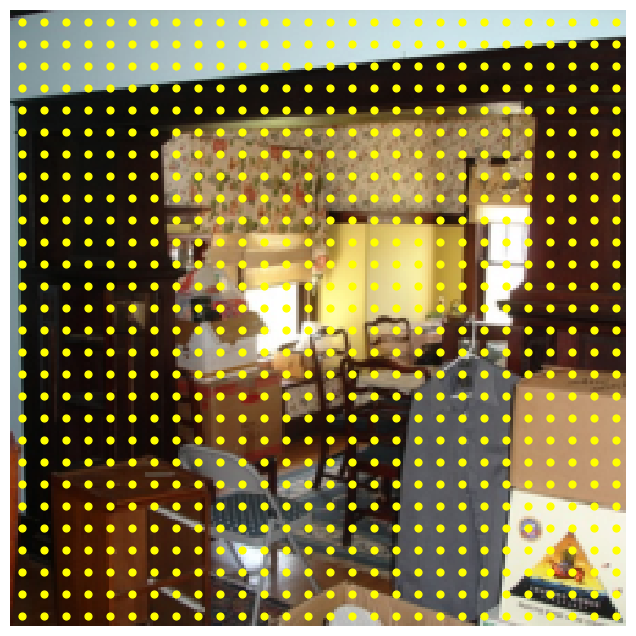

********************************************************************************
Visualizing all grid positions for FPN level: p4
corresponding stride = 16


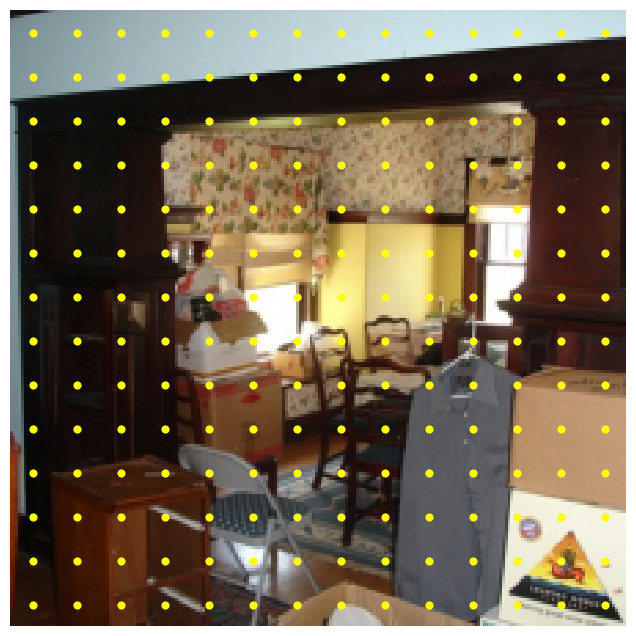

********************************************************************************
Visualizing all grid positions for FPN level: p5
corresponding stride = 32


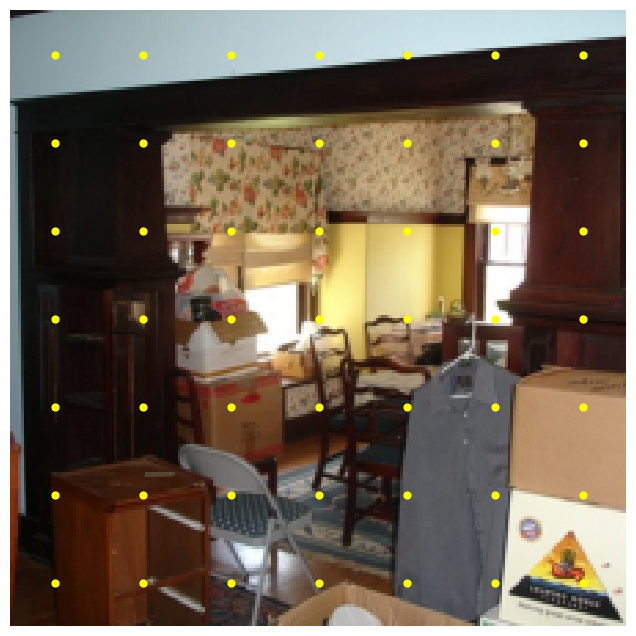

In [31]:
from common import get_my_fpn_location_coords

# Compute the spatial dimensions for each feature map extracted at various FPN levels.
# These aren’t based on feature values themselves, so we avoid calling them "dummy."
fpn_feats_shapes = {
    level_name: feat.shape for level_name, feat in dummy_fpn_feats.items()
}

# Generate location coordinates for each FPN level using CPU tensors.
# The function also allows an optional `device` argument if needed.
locations_per_fpn_level = get_my_fpn_location_coords(fpn_feats_shapes, backbone.fpn_strides)

# We'll now print the first five spatial positions for each feature map level.
expected_locations = {
    "p3": torch.tensor([[4.0, 4.0], [12.0, 4.0], [20.0, 4.0], [28.0, 4.0], [36.0, 4.0]]),
    "p4": torch.tensor([[8.0, 8.0], [24.0, 8.0], [40.0, 8.0], [56.0, 8.0], [72.0, 8.0]]),
    "p5": torch.tensor([[16.0, 16.0], [48.0, 16.0], [80.0, 16.0], [112.0, 16.0], [144.0, 16.0]]),
}

print("Preview of first five spatial coordinates per FPN level (in image space):")
for level_name, locations in locations_per_fpn_level.items():
    print(f"{level_name}: {locations[:5, :].tolist()}")
    print("relative error: ", rel_error(expected_locations[level_name], locations[:5, :]))

# Display the coordinate grid overlaid on the first validation image.
for level_name, locations in locations_per_fpn_level.items():
    # Convert the image back from normalized form to standard [0, 1] RGB format.
    image = inverse_norm(val_dataset[0][1])

    print("*" * 80)
    print(f"Visualizing all grid positions for FPN level: {level_name}")
    print(f"corresponding stride = {backbone.fpn_strides[level_name]}")
    det_vis(image, val_dataset.idx_to_class, points=locations.tolist())


### Assigning Feature Map Points to Ground Truth Boxes

In this part, we assign specific locations on the feature map to the corresponding ground truth (GT) bounding boxes. This step is essential for training the detector. The FCOS approach associates a set of `N` feature map points at each level of the FPN with `M` ground truth boxes using two key criteria:

> A point $N_i$ is linked to a box $M_i$ if it falls within the box boundaries. If the point is located inside multiple GT boxes, it is assigned to the one with the smallest area. If it is not inside any box, it is marked as "background".

> _Scale-aware assignment_ across FPN levels — each level of the FPN is responsible for boxes within a specific size range. For example, larger GT boxes are typically handled by `p5`, whereas smaller ones are assigned to `p3`.

Following this matching strategy, each location ends up with either:
- a 5D vector `(x1, y1, x2, y2, C)` representing the matched box and class label from the ground truth, or
- a background indicator `(-1, -1, -1, -1, -1)` if it doesn't match any box.

We've provided you with the implementation of this matching mechanism, as it’s a bit involved for the scope of this homework. Your task is to understand how to use it correctly by learning its inputs and outputs. You’ll find it in `my_detector.py` under the function name `fcos_match_my_locations_to_gt`.

You’re encouraged (but not required) to refer to Section 3.2 of the [FCOS paper](https://arxiv.org/abs/1904.01355) for more context.


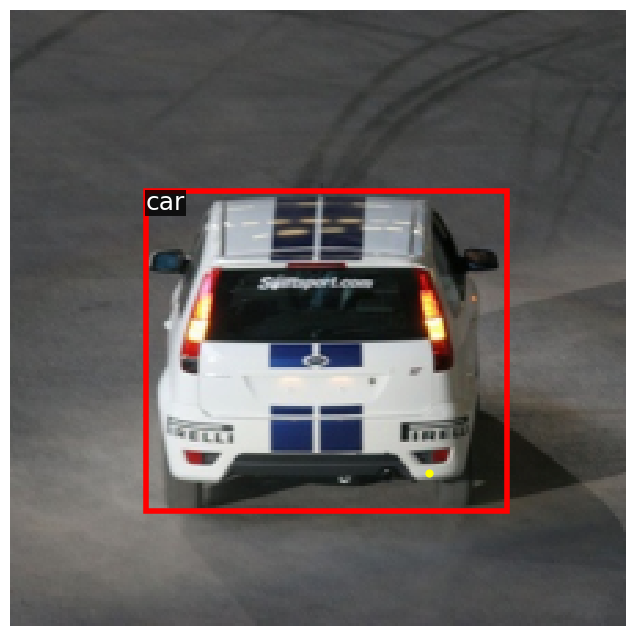

In [32]:
import random
from my_detector import fcos_match_my_locations_to_gt

# Pull a sample image and its ground truth annotations from the training split.
_, image, gt_boxes = train_dataset[0]

# `matched_boxes_per_fpn_level` is a dictionary mapping FPN levels (e.g. "p3", "p4", "p5")
# to tensors of shape (N, 5), where each row represents a ground truth box matched
# to a location at that feature level.
matched_boxes_per_fpn_level = fcos_match_my_locations_to_gt(
    locations_per_fpn_level, backbone.fpn_strides, gt_boxes
)

# We'll now visualize one location (shown in yellow) along with its matched
# ground truth box (in red). These examples come from a specific FPN level.
FPN_LEVEL = "p4"
fg_idxs_p3 = (matched_boxes_per_fpn_level[FPN_LEVEL][:, 4] != -1).nonzero()

# NOTE: You can re-run this cell to sample different valid points. 
# For example, in an image containing a car, only "p4" might have a match,
# since the object's size aligns best with the stride at that level.
_idx = random.choice(fg_idxs_p3)

det_vis(
    inverse_norm(image),
    val_dataset.idx_to_class,
    bbox=matched_boxes_per_fpn_level[FPN_LEVEL][_idx],
    points=locations_per_fpn_level[FPN_LEVEL][_idx]
)


In the diagram above, a random point on the `p3` feature map level is highlighted in **yellow**, with its corresponding ground truth box shown in **red**.

Given these assigned GT targets, the FCOS prediction modules are expected to perform three tasks at this point:
- Predict the correct class label (**person**) for this location,
- Estimate the distances from this point to each side of the bounding box `(left, top, right, bottom)`,
- Output a centerness score (a real-valued number) representing how centrally located this point is within the bounding box.

From this point forward, it will be helpful to narrow our focus to a _single_ location, assuming it has an associated ground truth box (or is labeled as background). We'll now walk through and implement the structure of the prediction outputs and the associated loss computations used during training.

## FCOS Box Regression Target Preparation

The goal of the box regression module is to predict four offset values: the distances from a specific feature map location (**yellow dot**) to the edges of a reference ground-truth box (**red rectangle**). These values are commonly expressed as `(left, top, right, bottom)`, or abbreviated as `LTRB`.

Note that all coordinates — whether feature points or ground-truth boxes — are expressed in absolute image coordinates, which may vary from `(0, 224)` for a standard input, to much larger ranges for bigger images.

However, having the model regress directly to such large values is problematic, as it can lead to unstable gradients and poor convergence. To address this, FCOS normalizes the `LTRB` targets by the stride of the FPN level in use. For example, assume we're working with the FPN level P3 where `stride = 8`. Let `(xc, yc)` represent a point on the feature map (**yellow dot**), and `(x1, y1, x2, y2)` denote the ground-truth box coordinates. The normalized box regression targets become:

```python
l = (xc - x1) / stride
t = (yc - y1) / stride
r = (x2 - xc) / stride
b = (y2 - yc) / stride
```

These values are sometimes referred to as regression "deltas". Since the model is trained to predict these deltas, we need to invert this transformation during inference to recover predicted boxes in the original image space.

In this exercise, you’ll write two functions to handle the forward and inverse transformations:

1. `fcos_get_the_deltas_from_locations`: Takes in the feature map locations and ground-truth boxes, and outputs the normalized deltas. This is used during training.
2. `fcos_apply_the_deltas_to_locations`: Takes in predicted deltas and the corresponding feature map locations, and reconstructs the predicted bounding boxes. This is used during inference.

Once you've implemented both, run the test cell provided to validate your code.


In [33]:
import torch

from my_detector import fcos_get_the_deltas_from_locations, fcos_apply_the_deltas_to_locations

# Define three sample bounding boxes, each paired with a single point located within.
# All boxes are marked as foreground using a placeholder class ID = 1.
input_boxes = torch.Tensor(
    [[10, 15, 100, 115, 1], [30, 20, 40, 30, 1], [120, 100, 200, 200, 1]]
)
input_locations = torch.Tensor([[30, 40], [32, 29], [125, 150]])

# Quick verification step: generate regression deltas based on box-point pairs,
# then invert them to recover the original boxes. A constant stride of 8 is used
# on both encoding and decoding sides to ensure consistency.
_deltas = fcos_get_the_deltas_from_locations(input_locations, input_boxes, stride=8)
output_boxes = fcos_apply_the_deltas_to_locations(_deltas, input_locations, stride=8)

print("Rel error in reconstructed boxes:", rel_error(input_boxes[:, :4], output_boxes))

# Additional check: when the target box is background (all -1 values),
# the computed deltas should also return -1.
# NOTE: As clarified in this assignment, background boxes are represented by all -1s.
background_box = torch.Tensor([[-1, -1, -1, -1, -1]])
input_location = torch.Tensor([[100, 200]])

_deltas = fcos_get_the_deltas_from_locations(input_location, background_box, stride=8)
output_box = fcos_apply_the_deltas_to_locations(_deltas, input_location, stride=8)

print("Backg delts should be all -1    :", _deltas)

# Since background deltas should not alter location, output box is expected
# to directly reflect the location point.
print("Output box with backg delts     :", output_box)


Rel error in reconstructed boxes: 0.0
Backg delts should be all -1    : tensor([[-1., -1., -1., -1.]])
Output box with backg delts     : tensor([[100., 200., 100., 200.]])


## Targets for Centerness

Given the ground-truth offsets from a point to the four boundaries of a box `(left, top, right, bottom)`, FCOS defines a centerness score as:

$$centerness = \sqrt{\frac{\min(left, right) \cdot \min(top, bottom)}{\max(left, right) \cdot \max(top, bottom)}}$$

This score reaches its peak (1) when the point lies exactly at the center of the box (`left = right` and `top = bottom`).
Conversely, points near the border of a box will result in centerness values approaching zero, as one or more distances become very small.

These centerness values are used as the learning targets for the centerness prediction branch.
Your task is to compute these targets in the function `fcos_make_centerness_targets`.

Run the following cell to validate your implementation — ensure that your relative error remains under `1e-7`.


In [34]:
import torch

from my_detector import fcos_make_my_centerness_targets

# Construct three predefined bounding areas with associated labels (1 = object).
# One entry is a placeholder for background, using sentinel values.
input_boxes = torch.Tensor(
    [
        [10, 15, 100, 115, 1],
        [30, 20, 40, 30, 1],
        [-1, -1, -1, -1, -1]  # denotes background region
    ]
)

# Define a set of spatial coordinates located within the above areas.
input_locations = torch.Tensor([[30, 40], [32, 29], [125, 150]])

# Ground truth for expected centerness response.
expected_centerness = torch.Tensor([0.30860671401, 0.1666666716, -1.0])

# Compute geometry offsets from point to box corners using the provided method.
_deltas = fcos_get_the_deltas_from_locations(input_locations, input_boxes, stride=8)

# Generate centerness indicators from the computed deltas.
centerness = fcos_make_my_centerness_targets(_deltas)

# Output the relative discrepancy between predicted and reference values.
print("Rel centerness err:", rel_error(centerness, expected_centerness))


Rel centerness err: 0.0


## Defining Loss Components

Once model predictions are matched to ground-truth (GT) targets during training, the next step is to compute the losses that guide the learning process.

The FCOS model produces predictions at three different levels, and each level contributes to the total training loss via the following components:

1. **Classification loss:** To address the issue of class imbalance (since many grid positions correspond to background), FCOS applies [Focal Loss](https://arxiv.org/abs/1708.02002). Focal Loss builds on top of cross-entropy by reducing the weight of easily classified examples — this helps avoid a model that just defaults to predicting "background" everywhere.

2. **Bounding box loss:** For the box localization task, we use a straightforward L1 loss to compare the predicted `LTRB` offsets to the GT values. Although the original FCOS paper uses [GIoU loss](https://giou.stanford.edu/) for slightly improved accuracy, we stick with L1 here due to training speed constraints in Colab. (Understanding GIoU is not necessary for this task.)

3. **Centerness loss:** This component deals with predicting how centrally located a point is within an object. Both predictions and targets are continuous values in the range `[0, 1]`, so the binary cross-entropy (BCE) loss is used here. While L1 is an alternative, BCE has shown better empirical results in practice.

**Final Loss Calculation:**  
Each spatial location can contribute up to three separate loss terms. However, the losses for box regression (2) and centerness (3) are not computed for background points, since those locations lack associated GT boxes and centerness scores. The overall training loss is the sum of valid loss terms, divided by the number of *foreground* points — those matched with at least one GT box.

Because the number of foreground points can vary a lot between images (depending on how crowded the scene is), we normalize the total loss using an *exponential moving average* of the foreground count — this helps keep training more stable. (This idea is similar in spirit to how running statistics are maintained in batch normalization.)

You've implemented similar losses in prior exercises, so now you're allowed to directly use PyTorch and Torchvision’s built-in loss functions. It’s a good idea to look into their documentation and code if you're curious about the details.

In the cells that follow, you'll see examples using dummy data to show how to correctly apply these loss functions. Carefully run and examine those examples before using them on the real predictions and targets from FCOS.


In [35]:
import torch
from torchvision.ops import sigmoid_focal_loss

# Quick validation setup: generate simulated classification outputs for two anchor points,
# assuming a classification task involving five distinct categories.
# Tensor shape: (batch_size, number_of_positions, total_classes)
dummy_pred_cls_logits = torch.randn(1, 2, 5)

# Simulated label data in one-hot encoded format, matching predicted shape.
# Example includes one active category (index 2), and one background-only entry.
# Tensor shape: (batch_size, number_of_positions, total_classes)
dummy_gt_classes = torch.Tensor([[[0, 0, 1, 0, 0], [0, 0, 0, 0, 0]]])

# Note: Remember focal loss function expects raw logits. DO NOT apply a sigmoid here!!!!!!!!!!!!!!!!!!
cls_loss = sigmoid_focal_loss(
    inputs=dummy_pred_cls_logits, targets=dummy_gt_classes
)

print("Computed classif. loss for data:")
print(cls_loss)

print(f"Total classification loss (without normalization): {cls_loss.sum()}")


Computed classif. loss for data:
tensor([[[1.1048, 1.1164, 0.0049, 0.0722, 0.4125],
         [0.0313, 0.1232, 0.1713, 0.0137, 0.7233]]])
Total classification loss (without normalization): 3.7734968662261963


In [36]:
from torch.nn import functional as F
from my_detector import fcos_get_the_deltas_from_locations

# Verification setup: simulate outputs from a model at TWO spatial positions
# with NUM_CLASSES = 2 (in real scenarios, there are often thousands of such positions).
# You can interpret these as two spatial anchors from the "p5" pyramid level.
dummy_locations = torch.Tensor([[32, 32], [64, 32]])
dummy_gt_boxes = torch.Tensor(
    [
        [1, 2, 40, 50, 2],
        [-1, -1, -1, -1, -1]  # Background or invalid instance for this slot.
    ]
)
# Arbitrary centerness ground truth (placeholder values for illustration):
dummy_gt_centerness = torch.Tensor([0.6, -1])

# Simulated model outputs:
# Shape: (batch_size, num_positions, 4 coords or 1 centerness)
dummy_pred_boxreg_deltas = torch.randn(1, 2, 4)
dummy_pred_ctr_logits = torch.randn(1, 2, 1)

# Flatten batch dimension for easier processing
dummy_pred_boxreg_deltas = dummy_pred_boxreg_deltas.view(-1, 4)
dummy_pred_ctr_logits = dummy_pred_ctr_logits.view(-1)

# Compute regression targets from locations and ground truth box corners
dummy_gt_deltas = fcos_get_the_deltas_from_locations(
    dummy_locations, dummy_gt_boxes[:, :4], stride=32
)

# Regression loss using L1 distance, scaled by 0.25 to average over 4 components (LTRB)
loss_box = 0.25 * F.l1_loss(
    dummy_pred_boxreg_deltas, dummy_gt_boxes[:, :4], reduction="none"
)

# Exclude positions marked as background:
loss_box[dummy_gt_deltas < 0] *= 0.0
print("Box regression loss (L1):", loss_box)

# Compute loss for centerness prediction using binary cross-entropy with logits
centerness_loss = F.binary_cross_entropy_with_logits(
    dummy_pred_ctr_logits, dummy_gt_centerness, reduction="none"
)
# Again, ignore background locations:
centerness_loss[dummy_gt_centerness < 0] *= 0.0
print("Centerness loss (BCE):", centerness_loss)

# Note: the first loss values are random since model outputs are random.
# However, entries corresponding to background (second value) should consistently yield zero loss!


Box regression loss (L1): tensor([[ 0.1217,  0.3227,  9.6964, 12.7065],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])
Centerness loss (BCE): tensor([0.6781, 0.0000])


## Detection Module Construction

Now it's time to bring all components together within the `FCOS` class found in `my_detector.py`.

Your task is to implement the `__init__` and `forward` methods of this class. Most of the core logic has already been handled in earlier steps—your goal here is to organize and invoke the relevant pieces properly.

To handle the loss computation inside `forward()`, refer back to the logic used in the prior two code blocks. You’ll just need to integrate them in this new structure.

## Tiny Dataset Overfitting

To validate that your model behaves correctly, try fitting it on a minimal slice of your dataset.

Initially, you might observe an increase in training loss due to exponential moving average (EMA), but the loss should decrease over time if things are working.

A helper function named `train_detector` has been created to manage the training loop for your detector. You can check out how it’s written by reviewing the code in `fcos_starter.py`.


For dummy input with shape: (2, 3, 224, 224)
Shape of c3 features: torch.Size([2, 64, 28, 28])
Shape of c4 features: torch.Size([2, 160, 14, 14])
Shape of c5 features: torch.Size([2, 400, 7, 7])
[Iter 0][loss: 1.757][loss_cls: 0.706][loss_box: 0.619][loss_ctr: 0.432]
[Iter 20][loss: 2.531][loss_cls: 0.873][loss_box: 0.990][loss_ctr: 0.668]
[Iter 40][loss: 2.437][loss_cls: 0.655][loss_box: 1.067][loss_ctr: 0.715]
[Iter 60][loss: 2.353][loss_cls: 0.560][loss_box: 1.075][loss_ctr: 0.719]
[Iter 80][loss: 2.282][loss_cls: 0.523][loss_box: 1.042][loss_ctr: 0.717]
[Iter 100][loss: 1.991][loss_cls: 0.451][loss_box: 0.829][loss_ctr: 0.711]
[Iter 120][loss: 2.048][loss_cls: 0.609][loss_box: 0.740][loss_ctr: 0.699]
[Iter 140][loss: 1.953][loss_cls: 0.556][loss_box: 0.701][loss_ctr: 0.696]
[Iter 160][loss: 1.952][loss_cls: 0.588][loss_box: 0.669][loss_ctr: 0.695]
[Iter 180][loss: 1.828][loss_cls: 0.499][loss_box: 0.649][loss_ctr: 0.680]
[Iter 200][loss: 2.003][loss_cls: 0.701][loss_box: 0.626][los

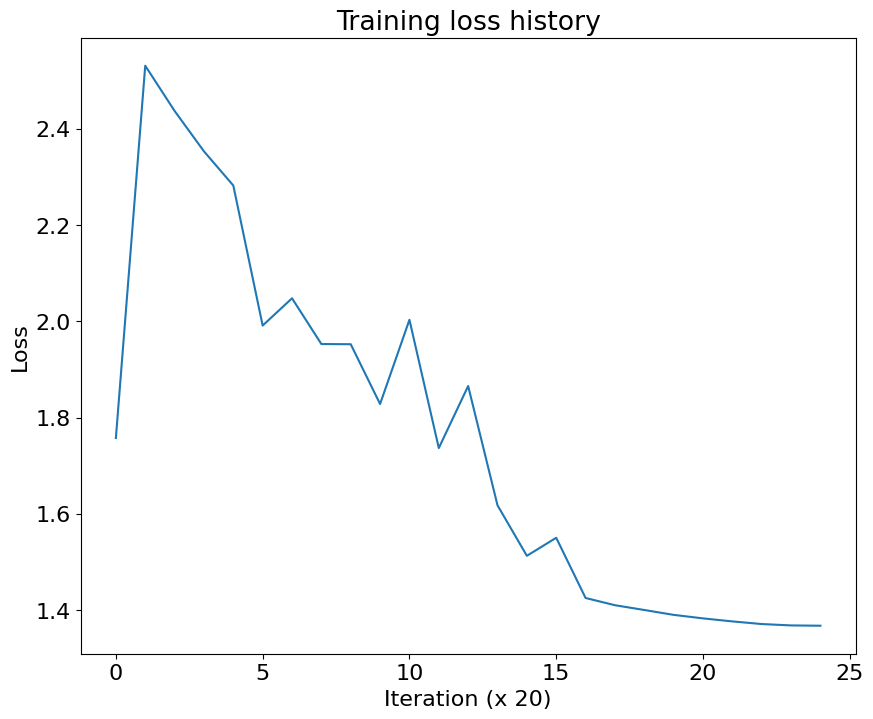

In [50]:
from fcos_starter import train_det
from my_detector import FCOS
from mycode.utils import reset_seed

reset_seed(0) # in utils file

# Take equally spaced examples from training dataset to make a subset.
small_dataset = torch.utils.data.Subset(
    train_dataset,
    torch.linspace(0, len(train_dataset) - 1, steps=BATCH_SIZE * 10).long()
)
small_train_loader = torch.utils.data.DataLoader(
    small_dataset, batch_size=BATCH_SIZE, pin_memory=True, num_workers=NUM_WORKERS
)

detector = FCOS(
    num_classes=NUM_CLASSES,
    fpn_channels=64,
    stem_channels=[64, 64],
)
detector = detector.to(COMPUTE_DEVICE)

train_det(
    detector,
    small_train_loader,
    learning_rate=5e-3,
    max_iters=500,
    log_period=20,
    device=COMPUTE_DEVICE,
)

## Model Training

Now that we've verified our training logic is functioning as expected, it's time to scale things up. We'll extend training to 9000 steps—this process may take around 30 minutes if you're running it on a K80 GPU. If you're just testing or troubleshooting, feel free to reduce the number of steps to something shorter (e.g., 1000) to save time.

Keep in mind: real-world object detection pipelines often train over the course of 12–24 hours, usually leveraging multiple GPUs and more powerful hardware. So while our setup won't reach cutting-edge performance, it should still be capable of producing reasonable results.

For dummy input with shape: (2, 3, 224, 224)
Shape of c3 features: torch.Size([2, 64, 28, 28])
Shape of c4 features: torch.Size([2, 160, 14, 14])
Shape of c5 features: torch.Size([2, 400, 7, 7])
[Iter 0][loss: 1.323][loss_cls: 0.529][loss_box: 0.466][loss_ctr: 0.329]
[Iter 100][loss: 1.844][loss_cls: 0.484][loss_box: 0.690][loss_ctr: 0.670]
[Iter 200][loss: 1.700][loss_cls: 0.429][loss_box: 0.596][loss_ctr: 0.675]
[Iter 300][loss: 1.556][loss_cls: 0.440][loss_box: 0.471][loss_ctr: 0.646]
[Iter 400][loss: 1.603][loss_cls: 0.406][loss_box: 0.509][loss_ctr: 0.688]
[Iter 500][loss: 1.236][loss_cls: 0.282][loss_box: 0.387][loss_ctr: 0.566]
[Iter 600][loss: 1.172][loss_cls: 0.263][loss_box: 0.356][loss_ctr: 0.553]
[Iter 700][loss: 1.354][loss_cls: 0.317][loss_box: 0.425][loss_ctr: 0.612]
[Iter 800][loss: 1.166][loss_cls: 0.234][loss_box: 0.373][loss_ctr: 0.559]
[Iter 900][loss: 1.335][loss_cls: 0.326][loss_box: 0.409][loss_ctr: 0.600]
[Iter 1000][loss: 1.437][loss_cls: 0.383][loss_box: 0.432

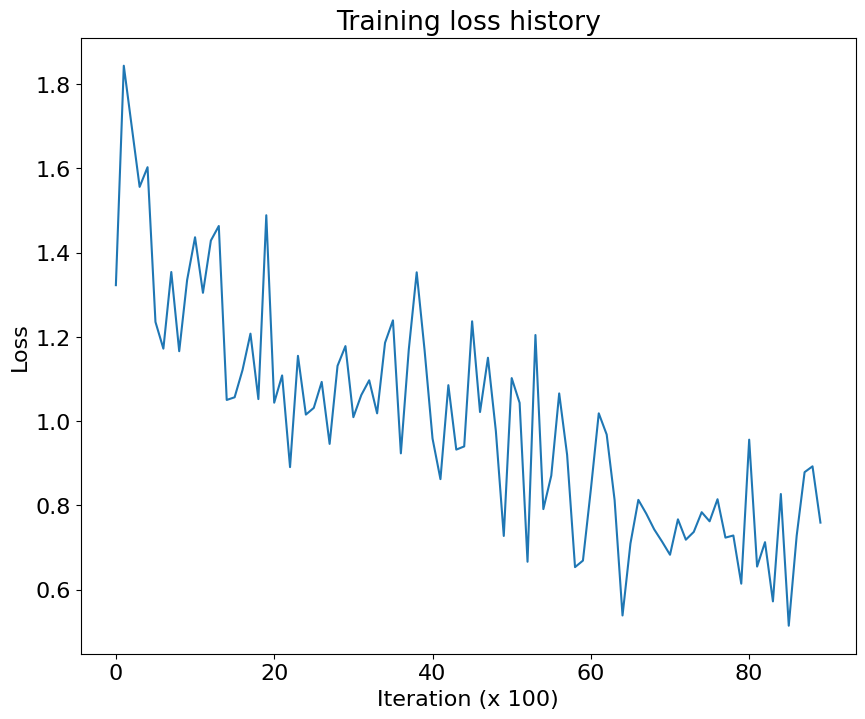

In [51]:
reset_seed(0)

# Initialize a slightly larger model variant 
detector = FCOS(
    num_classes=NUM_CLASSES,
    fpn_channels=128,
    stem_channels=[128, 128],
)
detector = detector.to(COMPUTE_DEVICE)

# Train the object localization network with the given parameters.
train_det(
    detector,
    train_loader,
    learning_rate=8e-3,
    max_iters=9000,
    log_period=100,
    device=COMPUTE_DEVICE,
)

# Once the model has been trained, persist the weight parameters for grading.
weights_path = os.path.join(GOOGLE_DRIVE_PATH, "my_fcos_det.pt")
torch.save(detector.state_dict(), weights_path)

## Non-Maximum Suppression (NMS)

Complete the `nms` routine inside the `my_detector.py` script. Afterward, we’ll validate your version by comparing its output against the built-in approach found in the `torchvision` toolkit. 

It’s likely that your method will show better performance when run on the CPU, while the `torchvision` variant will be significantly faster on a GPU. This is perfectly acceptable. However, it is crucial that your implementation yields identical results to the reference version provided by `torchvision`.






In [54]:
import time
import torch
import torchvision

from common import nms
from mycode import reset_seed

reset_seed(0)

# Generate synthetic bounding boxes and scores
boxes = (100.0 * torch.rand(5000, 4)).round()
boxes[:, 2] = boxes[:, 2] + boxes[:, 0] + 1.0
boxes[:, 3] = boxes[:, 3] + boxes[:, 1] + 1.0
scores = torch.randn(5000)

# Setup variant labels and evaluation parameters
names = ["your_cpu", "torchvision_cpu", "torchvision_cuda"]
#names = ["your_cpu", "torchvision_cpu"]
iou_thresholds = [0.3, 0.5, 0.7]
elapsed = dict(zip(names, [0.0] * len(names)))
intersects = dict(zip(names[1:], [0.0] * (len(names) - 1)))

# Run evaluation across different IoU thresholds
for iou_threshold in iou_thresholds:
    tic = time.time()
    my_keep = nms(boxes, scores, iou_threshold)
    elapsed["your_cpu"] += time.time() - tic

    tic = time.time()
    tv_keep = torchvision.ops.nms(boxes, scores, iou_threshold)
    elapsed["torchvision_cpu"] += time.time() - tic
    intersect = len(set(tv_keep.tolist()).intersection(my_keep.tolist())) / len(tv_keep)
    intersects["torchvision_cpu"] += intersect

    tic = time.time()
    tv_cuda_keep = torchvision.ops.nms(boxes.to(device=COMPUTE_DEVICE), scores.to(device=COMPUTE_DEVICE), iou_threshold).to(
        my_keep.device
    )
    torch.cuda.synchronize()
    elapsed["torchvision_cuda"] += time.time() - tic
    intersect = len(set(tv_cuda_keep.tolist()).intersection(my_keep.tolist())) / len(tv_cuda_keep)
    intersects["torchvision_cuda"] += intersect

# Average the intersection values over all IoU thresholds
for key in intersects:
    intersects[key] /= len(iou_thresholds)

# Output comparison of runtime and similarity for all versions
print("Evaluating Your NMS implementations:")
print("Your        CPU  implementation: %fs" % elapsed["your_cpu"])
print("torchvision's CPU  implementation: %fs" % elapsed["torchvision_cpu"])
print("torchvision's CUDA implementation: %fs" % elapsed["torchvision_cuda"])
print("Speedup on CPU : %fx" % (elapsed["your_cpu"] / elapsed["torchvision_cpu"]))
print("Speedup on CUDA: %fx" % (elapsed["your_cpu"] / elapsed["torchvision_cuda"]))
print("Deviation on CPU : ", 1.0 - intersects["torchvision_cpu"])  # should be ~0.001 or smaller
print("Deviation on CUDA: ", 1.0 - intersects["torchvision_cuda"])  # should be ~0.001 or smaller


Evaluating Your NMS implementations:
Your        CPU  implementation: 1.392096s
torchvision's CPU  implementation: 0.139079s
torchvision's CUDA implementation: 0.009999s
Speedup on CPU : 10.009416x
Speedup on CUDA: 139.219671x
Deviation on CPU :  0.0012674271229404788
Deviation on CUDA:  0.0


## Inferencing 

Refer to the `FCOS.inference` method and complete the necessary logic for performing predictions.

After implementing the required functionality, test your model by visualizing the prediction results on several evaluation images. Use the script below to help with this step. You should observe that the predicted bounding boxes roughly match the actual object locations. These predictions can be further refined with a larger network or extended training.


For dummy input with shape: (2, 3, 224, 224)
Shape of c3 features: torch.Size([2, 64, 28, 28])
Shape of c4 features: torch.Size([2, 160, 14, 14])
Shape of c5 features: torch.Size([2, 400, 7, 7])


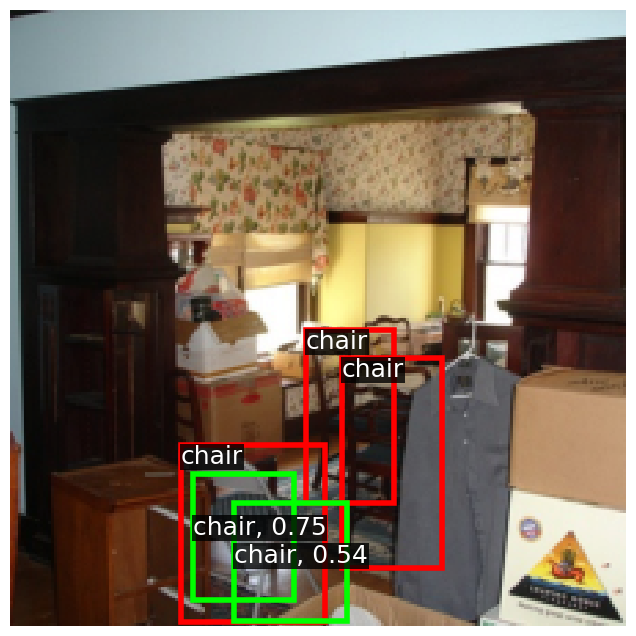

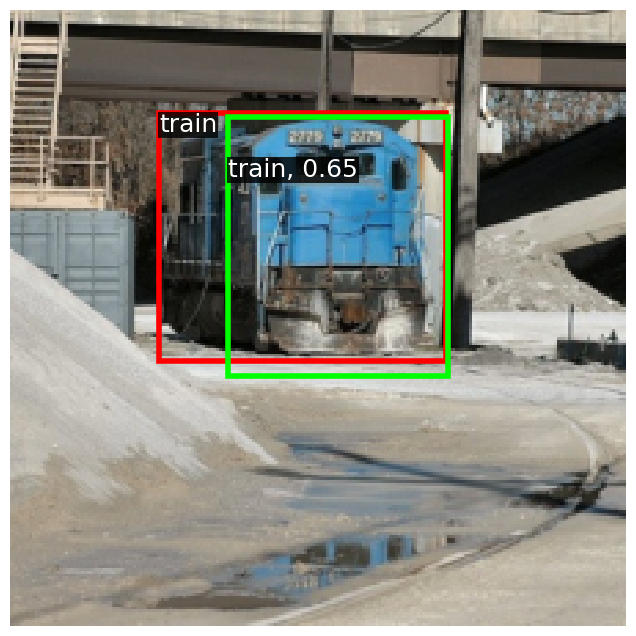

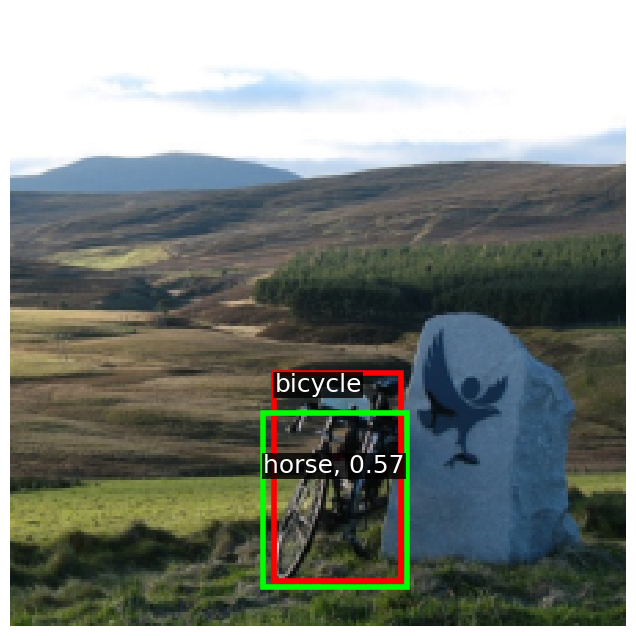

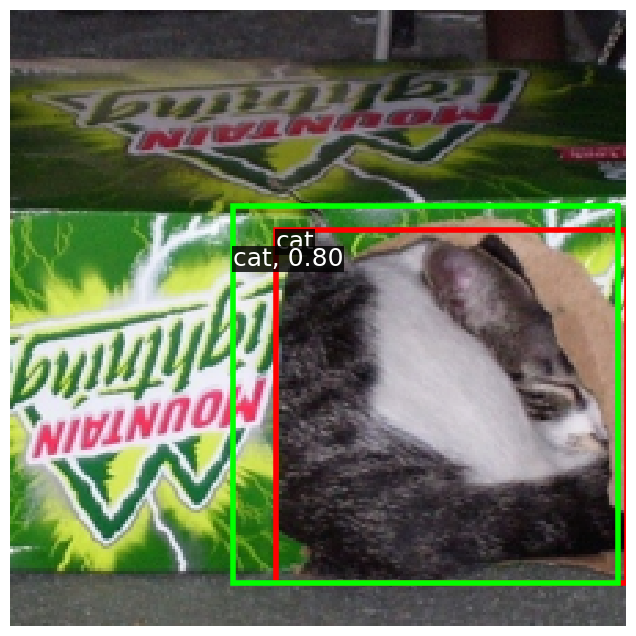

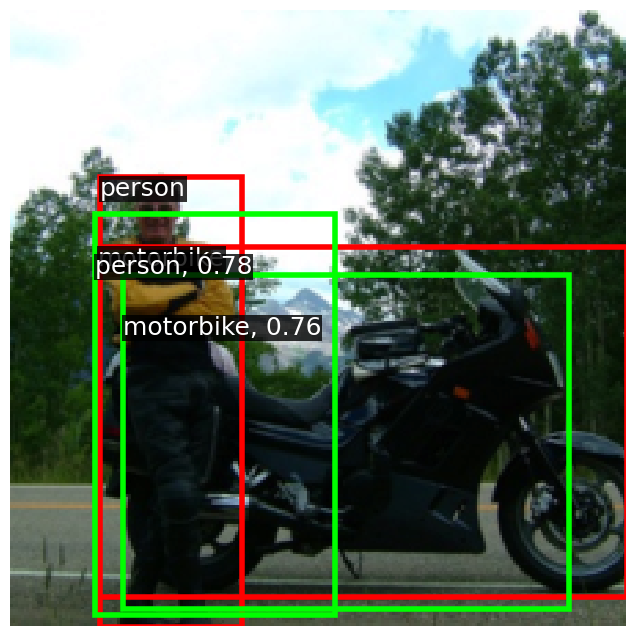

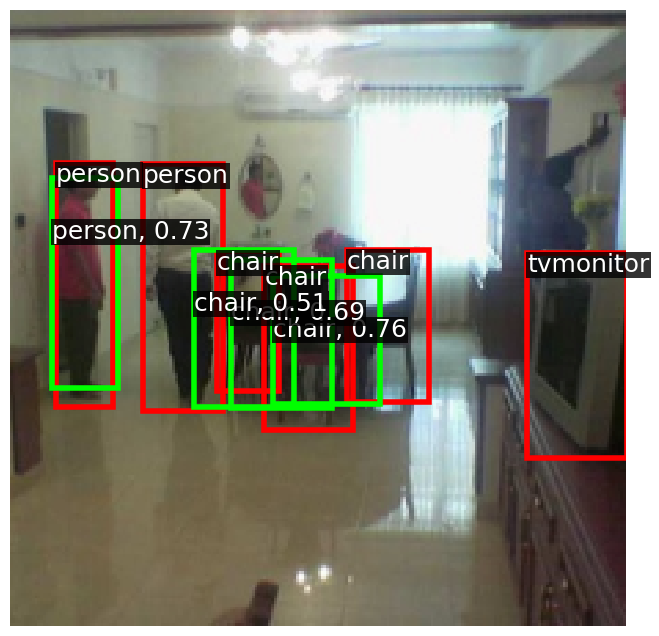

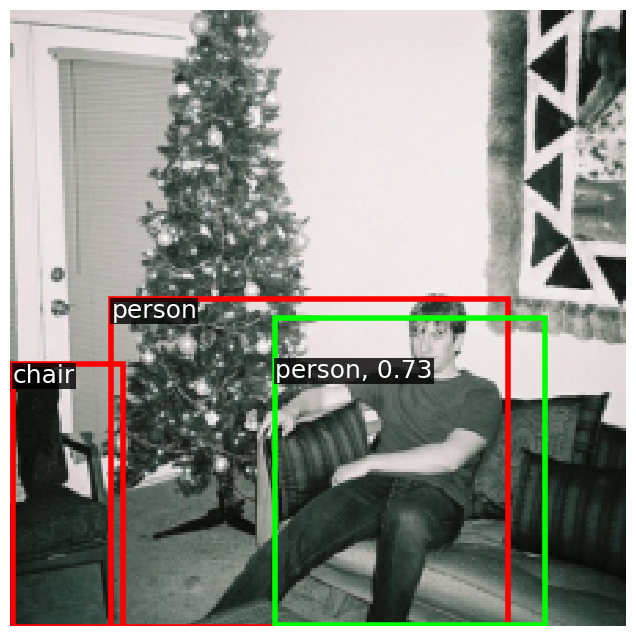

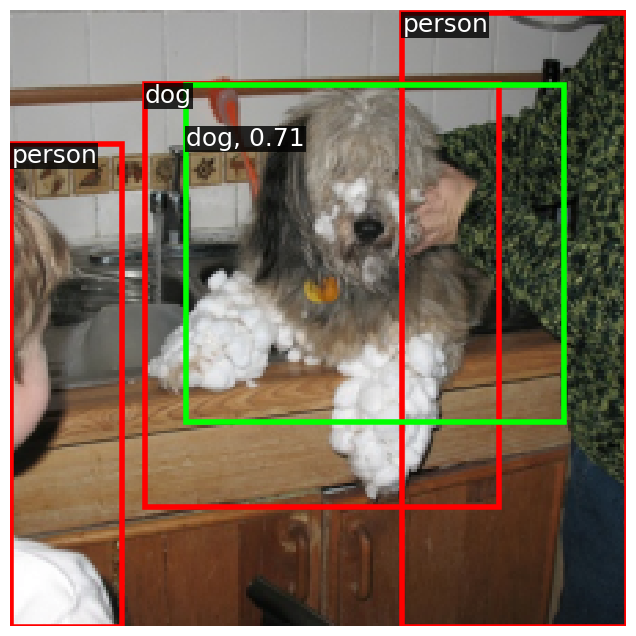

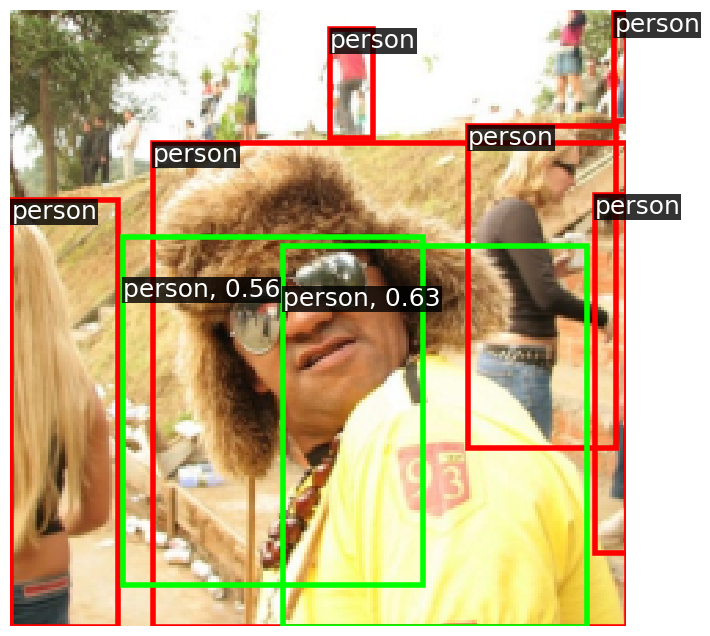

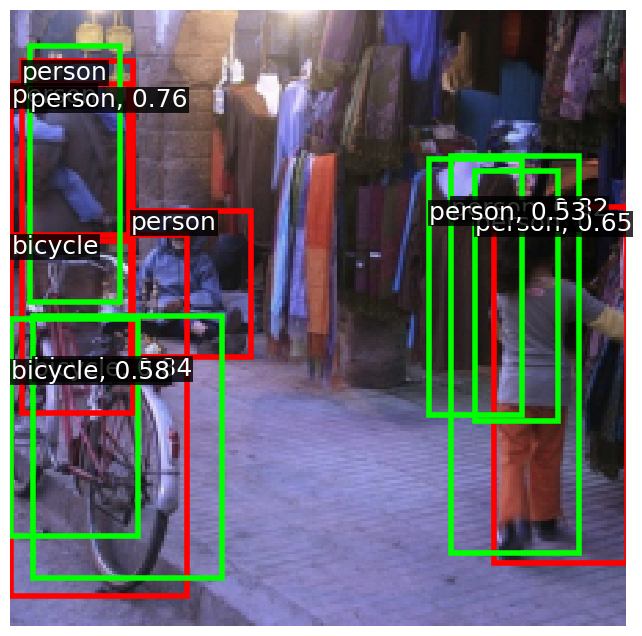

Total inference time: 2.6s


In [63]:
from fcos_starter import forward_detector
from my_detector import FCOS

# Path to pre-trained model weights
weights_path = os.path.join(GOOGLE_DRIVE_PATH, "my_fcos_det.pt")

# Freshly construct the detector to ensure independence from earlier cell states
detector = FCOS(
    num_classes=NUM_CLASSES,
    fpn_channels=128,
    stem_channels=[128, 128]
)
detector.to(device=COMPUTE_DEVICE)
detector.load_state_dict(torch.load(weights_path, map_location="cpu"))

# Create a trimmed-down validation set for quicker testing
subset_indices = torch.linspace(0, len(val_dataset) - 1, steps=10).long()
small_dataset = torch.utils.data.Subset(val_dataset, subset_indices)

small_val_loader = torch.utils.data.DataLoader(
    dataset=small_dataset,
    batch_size=1,
    pin_memory=True,
    num_workers=NUM_WORKERS
)

# Run inference using the detector
forward_detector(
    detector=detector,
    test_loader=small_val_loader,
    idx_to_class=val_dataset.idx_to_class,
    score_thresh=0.5,
    nms_thresh=0.5,
    device=COMPUTE_DEVICE,
    dtype=torch.float32
)


## Evaluation
Compute mean Average Precision (mAP).

To measure how well your detection model performs, run it on the validation split of the VOC dataset. This step should only take a few minutes. With the provided default settings, your implementation should be able to achieve a minimum of 22% mean average precision (mAP).

Note: Top-tier models on this benchmark reach over 80% mAP! However, hitting those numbers typically requires deeper architectures, significantly more training time, and larger datasets — all of which go beyond what's expected in this exercise.

Total inference time: 88.1s
65.95% = aeroplane AP 
54.27% = bicycle AP 
43.14% = bird AP 
26.57% = boat AP 
5.40% = bottle AP 
49.72% = bus AP 
48.44% = car AP 
66.98% = cat AP 
16.56% = chair AP 
38.73% = cow AP 
29.58% = diningtable AP 
56.54% = dog AP 
59.29% = horse AP 
50.35% = motorbike AP 
46.88% = person AP 
11.05% = pottedplant AP 
20.55% = sheep AP 
26.24% = sofa AP 
72.56% = train AP 
37.91% = tvmonitor AP 
mAP = 41.33%
Figure(640x480)


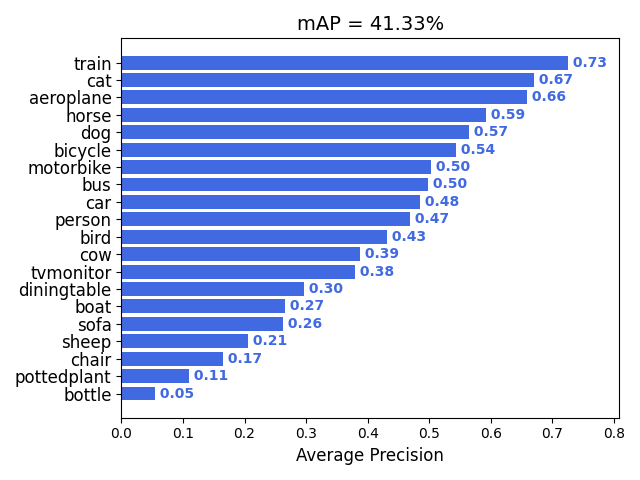

In [66]:
forward_detector(
    detector,
    val_loader,
    val_dataset.idx_to_class,
    score_thresh=0.4,
    nms_thresh=0.6,
    device=COMPUTE_DEVICE,
    dtype=torch.float32,
    output_dir="mAP/input",
)
!cd mAP && python main.py

from IPython.display import Image
Image(filename="./mAP/output/mAP.png") # You should get a performance chart here across categories!